# 기초통계 통합 프로젝트
## Part 1. 고객 구매 데이터 기술통계 및 이상치 분석

### 시나리오

온라인 쇼핑몰 데이터 분석팀은 고객 구매 데이터를 활용하여 고객의 전반적인 구매 특성을 파악하려고 합니다.

분석팀은 먼저 다음 내용을 확인해야 합니다.

- 고객의 평균적인 구매금액과 구매수량
- 고객 데이터가 얼마나 넓게 퍼져 있는지
- 구매금액 분포가 한쪽으로 치우쳐 진 구조인지
- 일반적인 고객과 차이가 큰 구매 데이터가 있는지

Part 1에서는 주요 기술통계량과 그래프를 이용하여 고객 구매 데이터의 기본 특성을 점검합니다.
이 결과는 이후 표본 분석, 상관관계 분석, 회귀예측에 공통으로 활용합니다.

### 과제 목표

- 평균, 중앙값, 분산, 표준편차를 계산할 수 있습니다.
- Q1, Q2, Q3를 계산하여 데이터의 위치를 확인할 수 있습니다.
- 히스토그램과 박스플롯으로 구매금액 분포를 확인할 수 있습니다.
- IQR 기준으로 이상치 후보를 찾을 수 있습니다.
- 계산 결과를 고객 구매 특성과 연결하여 설명할 수 있습니다.

### 사용 환경

- 결과물: `.ipynb` 파일 1개
- 사용 언어: Python 3.X
- 사용 라이브러리: pandas, matplotlib
- 사용 데이터: `online_shopping_customer_data.csv`


## 제공 코드. 고객 데이터 불러오기

아래 코드는 준비 코드이며 평가 대상이 아닙니다.

분석 대상 컬럼의 결측치가 있는 행을 제거하여 `analysis_df`를 생성합니다.
이후 Part에서도 동일한 전처리 기준을 사용합니다.


In [1]:
import pandas as pd
import matplotlib.pyplot as plt
%config InlineBackend.figure_format = 'retina'

DATA_FILE = "online_shopping_customer_data.csv"

df = pd.read_csv(DATA_FILE)

analysis_columns = ["PurchaseAmount", "PurchaseQty", "Age", "ReviewScore"]

analysis_df = df.dropna(subset=analysis_columns).copy()

print("전체 데이터 크기:", df.shape)
print("분석 데이터 크기:", analysis_df.shape)
print("분석 대상 컬럼:", analysis_columns)

analysis_df[analysis_columns].head()


전체 데이터 크기: (500, 13)
분석 데이터 크기: (486, 13)
분석 대상 컬럼: ['PurchaseAmount', 'PurchaseQty', 'Age', 'ReviewScore']


,PurchaseAmount,PurchaseQty,Age,ReviewScore
0,86900.0,4,41,4.7
1,287500.0,7,27,4.9
2,242100.0,5,46,3.9
3,300500.0,5,48,5.0
4,171400.0,2,19,4.1


# 문제 1. 주요 기술통계량 계산

## 업무 상황

분석팀은 고객의 평균적인 구매 수준과 데이터의 분포를 한눈에 확인할 수 있는 요약표를 만들려고 합니다.

## 요구사항

1. `PurchaseAmount`, `PurchaseQty`, `Age`, `ReviewScore`의 평균을 계산합니다.
2. 각 컬럼의 중앙값을 계산합니다.
3. 각 컬럼의 분산과 표준편차를 계산합니다.
4. Q1, Q2, Q3를 계산합니다.
5. 계산 결과를 하나의 표로 정리하여 출력합니다.
6. `PurchaseAmount`의 평균과 중앙값을 비교합니다.


In [2]:
# 문제 1 코드를 작성하세요.


analysis_columns = ["PurchaseAmount", "PurchaseQty", "Age", "ReviewScore"]


pd.DataFrame({
    'mean' : analysis_df[analysis_columns].mean().round(2),
    'median' : analysis_df[analysis_columns].median().round(2),
    'variance' : analysis_df[analysis_columns].var().round(2),
    'std' : analysis_df[analysis_columns].std().round(2),
    'Q1' : analysis_df[analysis_columns].quantile(0.25).round(2),
    'Q2' : analysis_df[analysis_columns].quantile(0.50).round(2),
    'Q3' : analysis_df[analysis_columns].quantile(0.75).round(2)
})


,mean,median,variance,std,Q1,Q2,Q3
PurchaseAmount,229961.52,216450.0,1.414358e+10,118926.78,158225.0,216450.0,280525.0
PurchaseQty,3.84,4.0,4.050000e+00,2.01,2.0,4.0,5.0
Age,37.94,38.0,9.769000e+01,9.88,31.0,38.0,44.0
ReviewScore,3.93,3.9,4.200000e-01,0.65,3.5,3.9,4.4


# 문제 2. 구매금액 분포와 이상치 후보 확인

## 업무 상황

고객 구매금액이 특정 구간에 집중되어 있는지 확인하고,
일반적인 고객과 차이가 큰 고액 또는 저액 구매 데이터를 찾으려고 합니다.

## 요구사항

1. `PurchaseAmount`의 히스토그램을 생성합니다.
2. `PurchaseAmount`의 박스플롯을 생성합니다.
3. Q1, Q3, IQR을 계산합니다.
4. IQR 기준의 하한값과 상한값을 계산합니다.
5. 하한값보다 작거나 상한값보다 큰 데이터를 이상치 후보로 추출합니다.
6. 이상치 후보의 개수와 `CustomerID`, `PurchaseAmount`를 출력합니다.

## IQR 기준

- 하한값: `Q1 - 1.5 × IQR`
- 상한값: `Q3 + 1.5 × IQR`


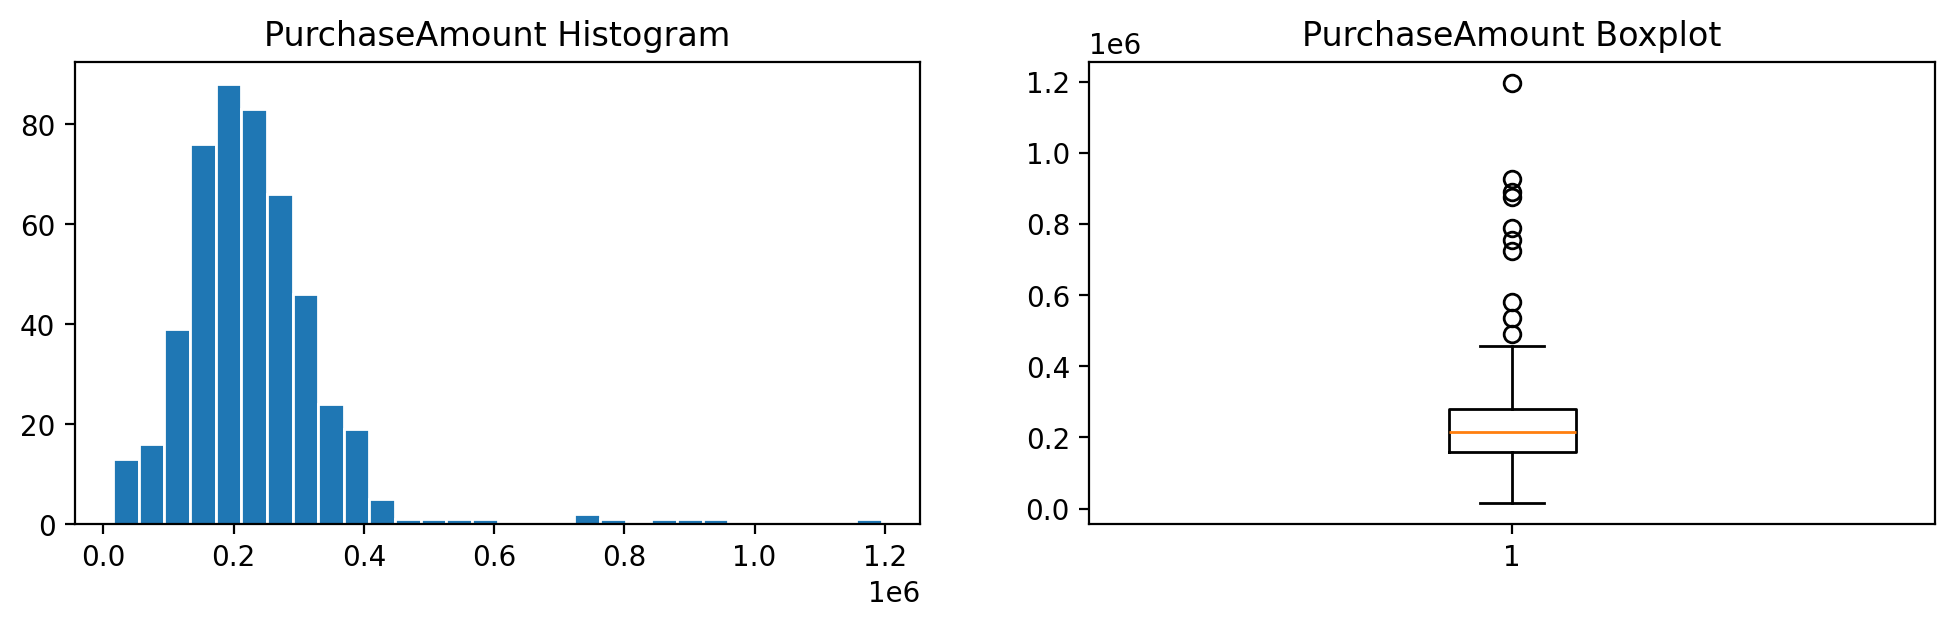

In [3]:
# 문제 2 코드를 작성하세요.

# 시각화
fig, axes = plt.subplots(1,2, figsize=(12, 3))

axes[0].hist(analysis_df['PurchaseAmount'], bins=30, edgecolor='white')
axes[1].boxplot(analysis_df['PurchaseAmount'])


axes[0].set_title('PurchaseAmount Histogram')
axes[1].set_title('PurchaseAmount Boxplot')


plt.show()

In [4]:
# IQR 작성 코드

Q1 = analysis_df['PurchaseAmount'].quantile(0.25).round(2)
Q3 = analysis_df['PurchaseAmount'].quantile(0.75).round(2)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR 
upper_bound = Q3 + 1.5 * IQR 

result = pd.DataFrame({
    'Q1' : Q1,
    'Q3' : Q3,
    'IQR' : IQR,
    'lower_bound' : lower_bound,
    'upper_bound' : upper_bound
}, index = ['PurchaseAmount'])


# 이상치 후보
outliers = analysis_df[(analysis_df['PurchaseAmount'] < lower_bound) | (analysis_df['PurchaseAmount'] > upper_bound)]


# 결과 출력
display(result)

print()
print('이상치 개수 :', len(outliers))
display(outliers[['CustomerID', 'PurchaseAmount']])


,Q1,Q3,IQR,lower_bound,upper_bound
PurchaseAmount,158225.0,280525.0,122300.0,-25225.0,463975.0



이상치 개수 : 10


,CustomerID,PurchaseAmount
31,CUST0032,788100.0
34,CUST0035,876500.0
77,CUST0078,889400.0
177,CUST0178,580400.0
179,CUST0180,489400.0
281,CUST0282,534500.0
299,CUST0300,1195500.0
319,CUST0320,925400.0
368,CUST0369,755900.0
390,CUST0391,725200.0


# 문제 3. 고객 구매 특성 해석

## 업무 상황

분석팀은 계산 결과를 마케팅 담당자가 이해할 수 있도록
구매금액의 기본적인 분포 특성으로 정리해야 합니다.

## 필수 요구사항

다음 내용을 포함하여 3문장 이상 작성합니다.

1. `PurchaseAmount`의 평균과 중앙값 중 어떤 값이 더 큰지 설명합니다.
2. 히스토그램과 박스플롯에서 확인한 구매금액 분포의 특징을 설명합니다.
3. IQR 기준으로 탐지된 이상치 후보의 개수를 설명합니다.


평균 : 229961.52
중앙값 : 216450.0


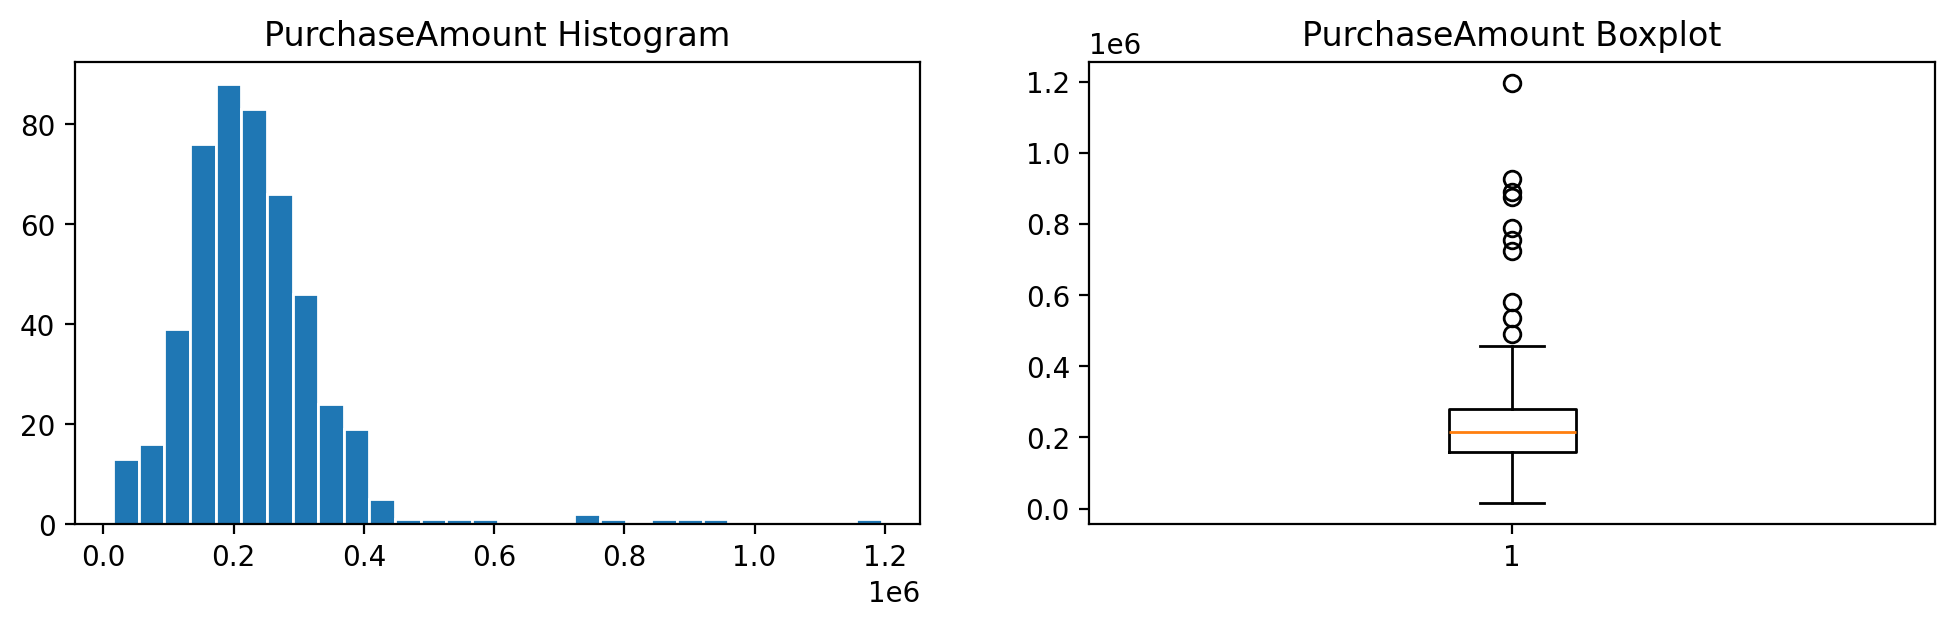

이상치 개수 : 10


In [5]:
# 문제 3 해석에 필요한 값을 출력하고, 아래 마크다운 셀에 해석을 작성하세요.

# 평균, 중앙값
print('평균 :', analysis_df['PurchaseAmount'].mean().round(2))
print('중앙값 :', analysis_df['PurchaseAmount'].median().round(2))

# 시각화
fig, axes = plt.subplots(1,2, figsize=(12, 3))

axes[0].hist(analysis_df['PurchaseAmount'], bins=30, edgecolor='white')
axes[1].boxplot(analysis_df['PurchaseAmount'])

axes[0].set_title('PurchaseAmount Histogram')
axes[1].set_title('PurchaseAmount Boxplot')

plt.show()

# IQR
print('이상치 개수 :', len(outliers))

#### **[결과]**
1. 구매 금액의 평균은 229,961원, 중앙값은 216,450원이므로 평균값이 중앙값보다 더 큰것으로 나타난다.
2. 히스토그램을 보았을 때 구매금액은 양의 왜도를 보이며 고객들은 낮은 가격을 중심으로 구매하는 것으로 나타난다. / 
   박스플롯 그래프를 보았을 때도 중앙보다 아래에 위치하여 양의 왜도를 보인다.
3. 사분위수를 이용하여 하한값, 상한값보다 상당히 낮거나 높은 극단값으로 구매한 고객의 데이터 수를 구한 결과 이상치 후보는 10개로 나타난다.

# 심화 문제. 이상치 후보의 업무적 의미 분석

이 문제는 필수 문제가 아니며, **심화 문제**입니다.

## 업무 상황

IQR 기준을 벗어난 구매금액이 발견되었지만,
해당 고객을 분석 데이터에서 바로 제거해도 되는지는 추가 확인이 필요합니다.

## 심화 요구사항

다음 내용을 포함하여 3문장 이상 작성합니다.

1. 이상치 후보가 입력 오류가 아닌 정상적인 고액 구매일 수 있는 사례를 제시합니다.
2. 이상치 후보를 바로 삭제하면 안 되는 이유를 설명합니다.
3. 이상치 처리 전에 추가로 확인해야 할 고객 또는 구매 정보를 작성합니다.


In [6]:
# 심화 문제 해석에 필요한 이상치 후보를 확인하세요.


# 제출 결과물

| 결과물 | 제출 내용 |
|---|---|
| 기술통계 요약표 | 평균, 중앙값, 분산, 표준편차, Q1, Q2, Q3 |
| 구매금액 분포 | 히스토그램과 박스플롯 |
| 이상치 탐지 결과 | IQR 기준, 이상치 후보 개수와 고객 정보 |
| 기본 해석 | 구매금액 분포와 이상치 후보 개수 설명 |
| 심화 해석 | 이상치의 업무적 의미와 처리 전 확인 사항(선택) |

# 제출 전 체크리스트

## 필수 문제

- [ ] 평균과 중앙값을 계산했습니다.
- [ ] 분산과 표준편차를 계산했습니다.
- [ ] Q1, Q2, Q3를 계산했습니다.
- [ ] 기술통계량을 하나의 표로 정리했습니다.
- [ ] 히스토그램과 박스플롯을 생성했습니다.
- [ ] IQR 기준으로 이상치 후보를 찾았습니다.
- [ ] 구매금액 분포와 이상치 후보 개수를 설명했습니다.

## 심화 문제

- [ ] 이상치 후보가 정상적인 고액 구매일 수 있는 사례를 작성했습니다.
- [ ] 이상치를 바로 삭제하면 안 되는 이유를 설명했습니다.
- [ ] 이상치 처리 전에 확인할 정보를 작성했습니다.
